# Импорты библиотек

In [2]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import scipy.stats as stats
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest


# Чтение данных

In [4]:
_FILE_NAME = "videostreaming_platform.csv"

df = pd.read_csv(_FILE_NAME)

df.head()

,user_id,start_trial_date,city,device,source,favourite_genre,avg_min_watch_daily,number_of_days_logged,churn
0,d1b6ef34-1991-452a-8c39-c83c0d5805fe,2024-02-01,St Petersburg,ios,performance,drama,2.076642,4,1
1,f1bf2396-73d8-461e-a775-9f068bd99326,2024-02-01,Other,web,seo,criminal,5.101392,1,1
2,ec9fa0be-4bd8-4fe6-910a-e9e6d4bbba28,2024-02-01,Ufa,web,performance,criminal,2.906597,1,1
3,b0195e96-af2e-4ac3-8f60-26b8d862af84,2024-02-01,Moscow,smarttv,seo,thriller,2.702388,6,0
4,a208985a-7244-4291-8d38-64c8141e27b2,2024-02-01,Ufa,web,performance,thriller,10.237305,1,1


# Первичный анализ данных

**Вывод общей информации**

In [7]:
rows, cols = df.shape
print(f'Количество строк: {rows}, количество столбцов: {cols}\n')
print("============== Информация о датасете =============\n")
display(df.info())
print("============== Описательные статистики датасета =============\n")
display(df.describe())

Количество строк: 28000, количество столбцов: 9

============== Информация о датасете =============

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                28000 non-null  object 
 1   start_trial_date       28000 non-null  object 
 2   city                   27692 non-null  object 
 3   device                 28000 non-null  object 
 4   source                 28000 non-null  object 
 5   favourite_genre        20048 non-null  object 
 6   avg_min_watch_daily    28000 non-null  float64
 7   number_of_days_logged  28000 non-null  int64  
 8   churn                  28000 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 1.9+ MB


None

============== Описательные статистики датасета =============



,avg_min_watch_daily,number_of_days_logged,churn
count,28000.000000,28000.00000,28000.000000
mean,7.812663,1.88600,0.789286
std,7.739760,1.48293,0.407823
min,0.000181,1.00000,0.000000
25%,2.521966,1.00000,1.000000
50%,5.419012,1.00000,1.000000
75%,10.487946,2.00000,1.000000
max,80.072401,7.00000,1.000000


**Приведение start_trial_date к типу datetime**

In [9]:
df['start_trial_date'] = pd.to_datetime(df['start_trial_date'])

**Проверка на дубликаты**

In [11]:
rows_before = df.shape[0]
df.drop_duplicates()
rows_after = df.shape[0]
print('Нет удалённых дублированных строк') if rows_before == rows_after else print(f'Удалено дублей: {rows_before - rows_after}')

Нет удалённых дублированных строк


**Проверка дублей строк по user_id**

In [13]:
duplicated_by_id = df[df.duplicated(subset=['user_id'])]
print('Дубли строк по user_id', duplicated_by_id) if duplicated_by_id.size else print('Нет дублей строк по user_id')

Нет дублей строк по user_id


**Проверка колонок на пустые значения**

user_id: 0
start_trial_date: 0
city: 308
device: 0
source: 0
favourite_genre: 7952
avg_min_watch_daily: 0
number_of_days_logged: 0
churn: 0


<Axes: >

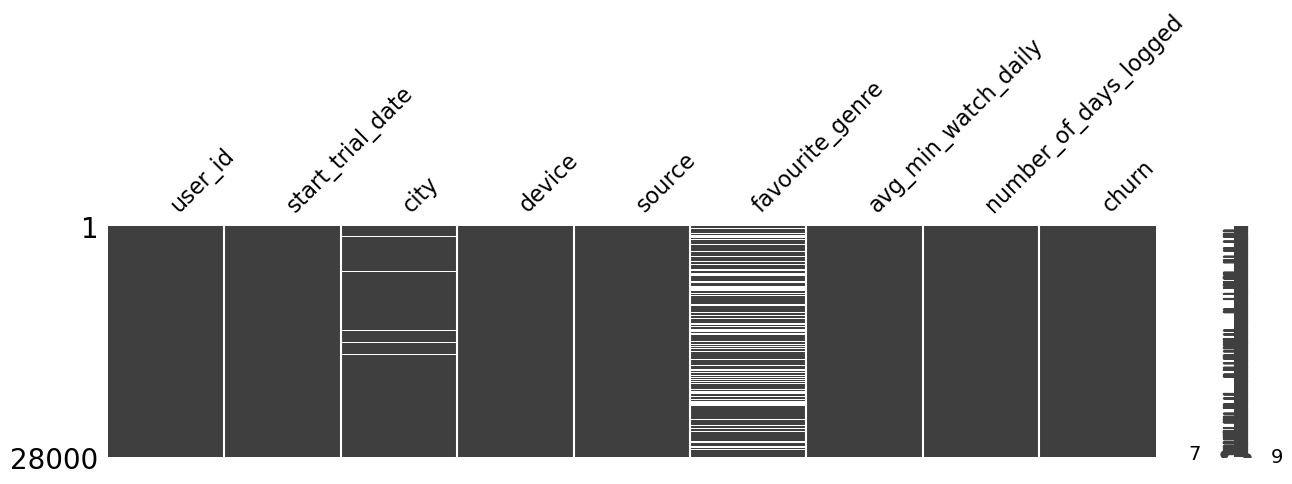

In [15]:
for column in df.columns:
    print(f'{column}: {df[column].isna().sum()}')
msno.matrix(df, figsize=(15, 3))

In [16]:
missing_summary = pd.DataFrame({
    'Количество': df.isna().sum(),
    'Пустых значений, %': (df.isna().sum() / len(df)) * 100
})
display(missing_summary)

,Количество,"Пустых значений, %"
user_id,0,0.0
start_trial_date,0,0.0
city,308,1.1
device,0,0.0
source,0,0.0
favourite_genre,7952,28.4
avg_min_watch_daily,0,0.0
number_of_days_logged,0,0.0
churn,0,0.0


**Первичный анализ времени просмтра**

In [18]:
# Предположим, что пользователь не может смотреть видео меньше 0.25 минуты
watch_daily_err = (df.avg_min_watch_daily <= 0.25).sum()
print(f'Строк с предположительно ошибочным временем просмотра: {watch_daily_err}, это {watch_daily_err/ (df.avg_min_watch_daily).sum() * 100} % от данных')

Строк с предположительно ошибочным временем просмотра: 817, это 0.3734779286816701 % от данных


**Так как данные по городу и по жанру значимы, то для дальнейшей корректной кодировки заменим их на значения None**

In [20]:
df['city'] = df['city'].fillna('None')
df['favourite_genre'] = df['favourite_genre'].fillna('None')

**Статистика столбцов**

In [22]:
print("========= Статистика по числовым колонкам ========")
display(df.describe())
print("====== Статистика по колонкам типа 'object' ======")
display(df.describe(include='object'))

========= Статистика по числовым колонкам ========


,start_trial_date,avg_min_watch_daily,number_of_days_logged,churn
count,28000,28000.000000,28000.00000,28000.000000
mean,2024-02-14 09:20:34.285714176,7.812663,1.88600,0.789286
min,2024-02-01 00:00:00,0.000181,1.00000,0.000000
25%,2024-02-07 00:00:00,2.521966,1.00000,1.000000
50%,2024-02-14 00:00:00,5.419012,1.00000,1.000000
75%,2024-02-21 00:00:00,10.487946,2.00000,1.000000
max,2024-02-28 00:00:00,80.072401,7.00000,1.000000
std,NaN,7.739760,1.48293,0.407823


====== Статистика по колонкам типа 'object' ======


,user_id,city,device,source,favourite_genre
count,28000,28000,28000,28000,28000
unique,28000,10,4,3,6
top,d1b6ef34-1991-452a-8c39-c83c0d5805fe,Moscow,web,performance,None
freq,1,8736,17752,14540,7952


**Описательная статистика для категориальных признаков**

In [24]:
def descriptive_statistics(df: pd.DataFrame, features: list[str]):   
    result = {}
    for feature in features:
        unique_values = df[feature].unique()
        result[feature] = {
            'Уникальные значения:': unique_values.tolist(),
            'Количество уникальных значений:': len(unique_values),
            'Доля уникальных значений:': df[feature].value_counts(normalize=True)
        }
    return result
def show_descriptive_statistics(statistics):
    for key, value in statistics.items():
        print(key, ': ')
        for k, v in value.items():
            print('> ', k,'\n', str(v))
        print('-' * 40)
categorical_features = 'city,device,source,favourite_genre'.split(',')
statistics = descriptive_statistics(df, categorical_features) # type: ignore
show_descriptive_statistics(statistics)

city : 
>  Уникальные значения: 
 ['St Petersburg', 'Other', 'Ufa', 'Moscow', 'Samara', 'Krasnodar', 'Yekaterinburg', 'Novosibirsk', 'Voronezh', 'None']
>  Количество уникальных значений: 
 10
>  Доля уникальных значений: 
 city
Moscow           0.312000
St Petersburg    0.160000
Other            0.095000
Krasnodar        0.091964
Novosibirsk      0.079036
Yekaterinburg    0.069000
Samara           0.067000
Ufa              0.059000
Voronezh         0.056000
None             0.011000
Name: proportion, dtype: float64
----------------------------------------
device : 
>  Уникальные значения: 
 ['ios', 'web', 'smarttv', 'android']
>  Количество уникальных значений: 
 4
>  Доля уникальных значений: 
 device
web        0.634
smarttv    0.127
android    0.122
ios        0.117
Name: proportion, dtype: float64
----------------------------------------
source : 
>  Уникальные значения: 
 ['performance', 'seo', 'organic']
>  Количество уникальных значений: 
 3
>  Доля уникальных значений: 
 sourc

> **Анализ датасета:**  
> - размер датасета - 8 столбцов и 28000 строк  
> - данные в формате `object`, `float64`, `int64`, привели `start_trial_date` к формату `datetime`
> - дубликатов по строкам или по ID нет
> - есть пропуски в `city` - 308 и в `favourite_genre` - 7952, которые заменены на 'None' для дальнейшей корректной кодировки
> 
> **Анализ столбцов:**  
> - данные представлены в промежутке с `01.02.2024` по `28.02.2024`
> - `avg_min_watch_daily` в промежутке от 0.000181 до 80.072401 минут, медиана 7.8 минут и среднее 5.4 отличнаются, что может говорить о выбросах. Минимальное время 0.000181 может говорить об ошибке в данных
> - `number_of_days_logged` от 1 до 7 дней, срденее - 1, медиана - 1.88, Что означает, что длительность триального периода вероятно - 7 дней, и большинство логируются только менее 2 дней
> - показатель отсутсвия покупки подписки `churn` - среднее 0.78, что говорит о 78% тех, кто не купил подписку после траильного периода
> - в `city` всего 10 значений: 'St Petersburg', 'Other', 'Ufa', 'Moscow', 'Samara', 'Krasnodar',
       'Yekaterinburg', 'Novosibirsk', 'Voronezh', 'None', самое популярное  - 'Moscow'
> - в `device` всего 4 значения: 'ios', 'web', 'smarttv', 'android', самое популярное  - 'web'
> - в `source` всего 3 значения: 'performance', 'seo', 'organic', самое популярное  - 'performance'
> - в `favourite_genre` всего 6 значений: 'drama', 'criminal', 'thriller', 'comedy', 'None', 'action', самое популярное - 'None'

# Очистка данных

**Удаление выбросов**

In [28]:
def remove_outliers_iqr(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    '''
    Функция удаляет выбросы по методу IQR
    '''
    for column in columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr 
        upper_bound = q3 + 1.5 * iqr
        df = df[ 
            (df[column] >= lower_bound) & (df[column] <= upper_bound)
            ] 
    return df
numerals = ['avg_min_watch_daily', 'number_of_days_logged']
print(f'Строк до удаления выбросов: {df.shape[0]}')
df = remove_outliers_iqr(df, columns=numerals)
print(f'Строк после удаления выбросов: {df.shape[0]}')

Строк до удаления выбросов: 28000
Строк после удаления выбросов: 22993


## EDA

### Кодировка

Для всех категориальных столбцов применим метод One-Hot Encoding, так как это создавст новые столбцы с признаками, но при этом не будет значений 0, 1, 2... как в Label Encoding, что может привести к ошибки ML модели, так как наши данные равнозначны между собой, в отличие от, напрмиер категорий возраста

In [32]:
df_encoded = pd.get_dummies(
    df, columns=[
        'city',
        'device',
        'source',
        'favourite_genre'
    ], drop_first=False)

df_encoded = df_encoded.rename(columns={
    'city_Moscow': 'c_msk',
    'city_St Petersburg': 'c_spb', 
    'city_Novosibirsk': 'c_nsk',
    'city_Yekaterinburg': 'c_ekb',
    'city_Krasnodar': 'c_krd',
    'city_Samara': 'c_sam',
    'city_Voronezh': 'c_vrn',
    'city_Ufa': 'c_ufa',
    'city_Other': 'c_other',
    'city_None': 'c_none', 
    'device_web': 'd_web',
    'device_ios': 'd_ios',
    'device_android': 'd_android',
    'device_smarttv': 'd_smarttv',
    'source_performance': 's_perf',
    'source_organic': 's_org',
    'source_seo': 's_seo',
    'favourite_genre_drama': 'fg_drama',
    'favourite_genre_criminal': 'fg_criminal',
    'favourite_genre_thriller': 'fg_thriller',
    'favourite_genre_comedy': 'fg_comedy',
    'favourite_genre_action': 'fg_action',
    'favourite_genre_None': 'fg_none'
})
df = df_encoded.join(df[['city', 'device', 'source', 'favourite_genre']])

In [33]:
pd.set_option('display.max_columns', None)

In [34]:
display(
    df.sample(10),
    df.info()
)

<class 'pandas.core.frame.DataFrame'>
Index: 22993 entries, 1 to 27999
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                22993 non-null  object        
 1   start_trial_date       22993 non-null  datetime64[ns]
 2   avg_min_watch_daily    22993 non-null  float64       
 3   number_of_days_logged  22993 non-null  int64         
 4   churn                  22993 non-null  int64         
 5   c_krd                  22993 non-null  bool          
 6   c_msk                  22993 non-null  bool          
 7   c_none                 22993 non-null  bool          
 8   c_nsk                  22993 non-null  bool          
 9   c_other                22993 non-null  bool          
 10  c_sam                  22993 non-null  bool          
 11  c_spb                  22993 non-null  bool          
 12  c_ufa                  22993 non-null  bool          
 13  c_vrn 

,user_id,start_trial_date,avg_min_watch_daily,number_of_days_logged,churn,c_krd,c_msk,c_none,c_nsk,c_other,c_sam,c_spb,c_ufa,c_vrn,c_ekb,d_android,d_ios,d_smarttv,d_web,s_org,s_perf,s_seo,fg_none,fg_action,fg_comedy,fg_criminal,fg_drama,fg_thriller,city,device,source,favourite_genre
19583,19f2fc5b-64a7-40d6-8313-cbb5d62025f4,2024-02-20,3.109238,3,1,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,St Petersburg,android,organic,action
1460,f3449f0c-723e-4cc2-9d87-0606d620864d,2024-02-02,16.054984,2,0,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,Krasnodar,android,organic,thriller
2467,290dcb03-bd09-4a9e-8bb3-4886f0ff1833,2024-02-03,4.391047,1,1,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,Krasnodar,web,performance,thriller
26308,8c2f1ab8-7c67-4074-92a5-638360814be5,2024-02-27,2.383828,2,1,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,St Petersburg,android,seo,drama
7049,81ee2720-1972-413d-b1e2-49a08ef2f5f7,2024-02-07,14.394658,1,1,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,True,Voronezh,android,performance,thriller
8887,02389581-c90f-4569-b3a7-a5917eee46e1,2024-02-09,16.610725,1,1,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,Other,web,seo,comedy
5753,c0a318dc-e5fd-41da-b8e7-a57be94b7c06,2024-02-06,5.162344,1,1,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,Novosibirsk,web,performance,thriller
27084,3c38c15f-04c6-484c-90e7-68f639d8a45f,2024-02-28,2.459683,1,1,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False,False,False,Yekaterinburg,smarttv,organic,action
16274,d89caa30-6650-4d43-8687-3fb80bf37c6b,2024-02-17,3.915175,2,1,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,False,False,Other,web,performance,None
1797,5ce423be-b2f1-4620-bf57-70edc83a6a60,2024-02-02,0.295659,2,1,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,St Petersburg,web,performance,action


None

### Оценка корреляции

interval columns not set, guessing: ['avg_min_watch_daily', 'number_of_days_logged', 'churn']


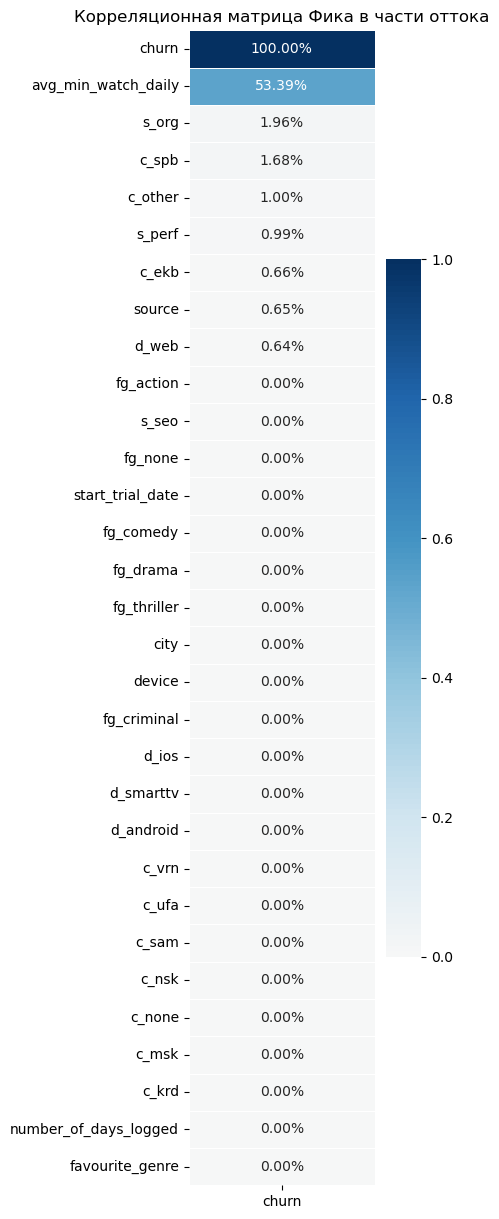

In [36]:
phik_corr_matrix = df.drop(columns='user_id').phik_matrix()
churn_phik_corr = phik_corr_matrix[['churn']].sort_values(by='churn', ascending=False)
plt.figure(figsize=(3, 15))
sns.heatmap(churn_phik_corr, annot=True, cmap='RdBu', center=0, fmt='.2%', linewidths=0.5)
plt.title('Корреляционная матрица Фика в части оттока')
plt.show()

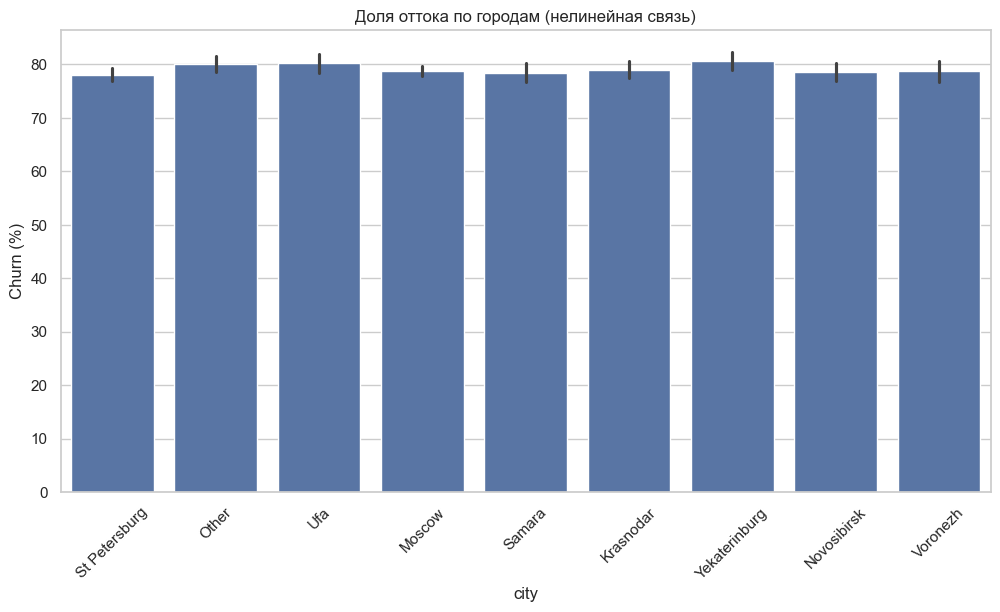

In [215]:
# Пример для города
plt.figure(figsize=(12, 6))
sns.barplot(x='city', y='churn', data=df, estimator=lambda x: sum(x)*100/len(x))
plt.xticks(rotation=45)
plt.title('Доля оттока по городам (нелинейная связь)')
plt.ylabel('Churn (%)')
plt.show()

### Исследование данных в колонках

#### `avg_min_watch_daily`

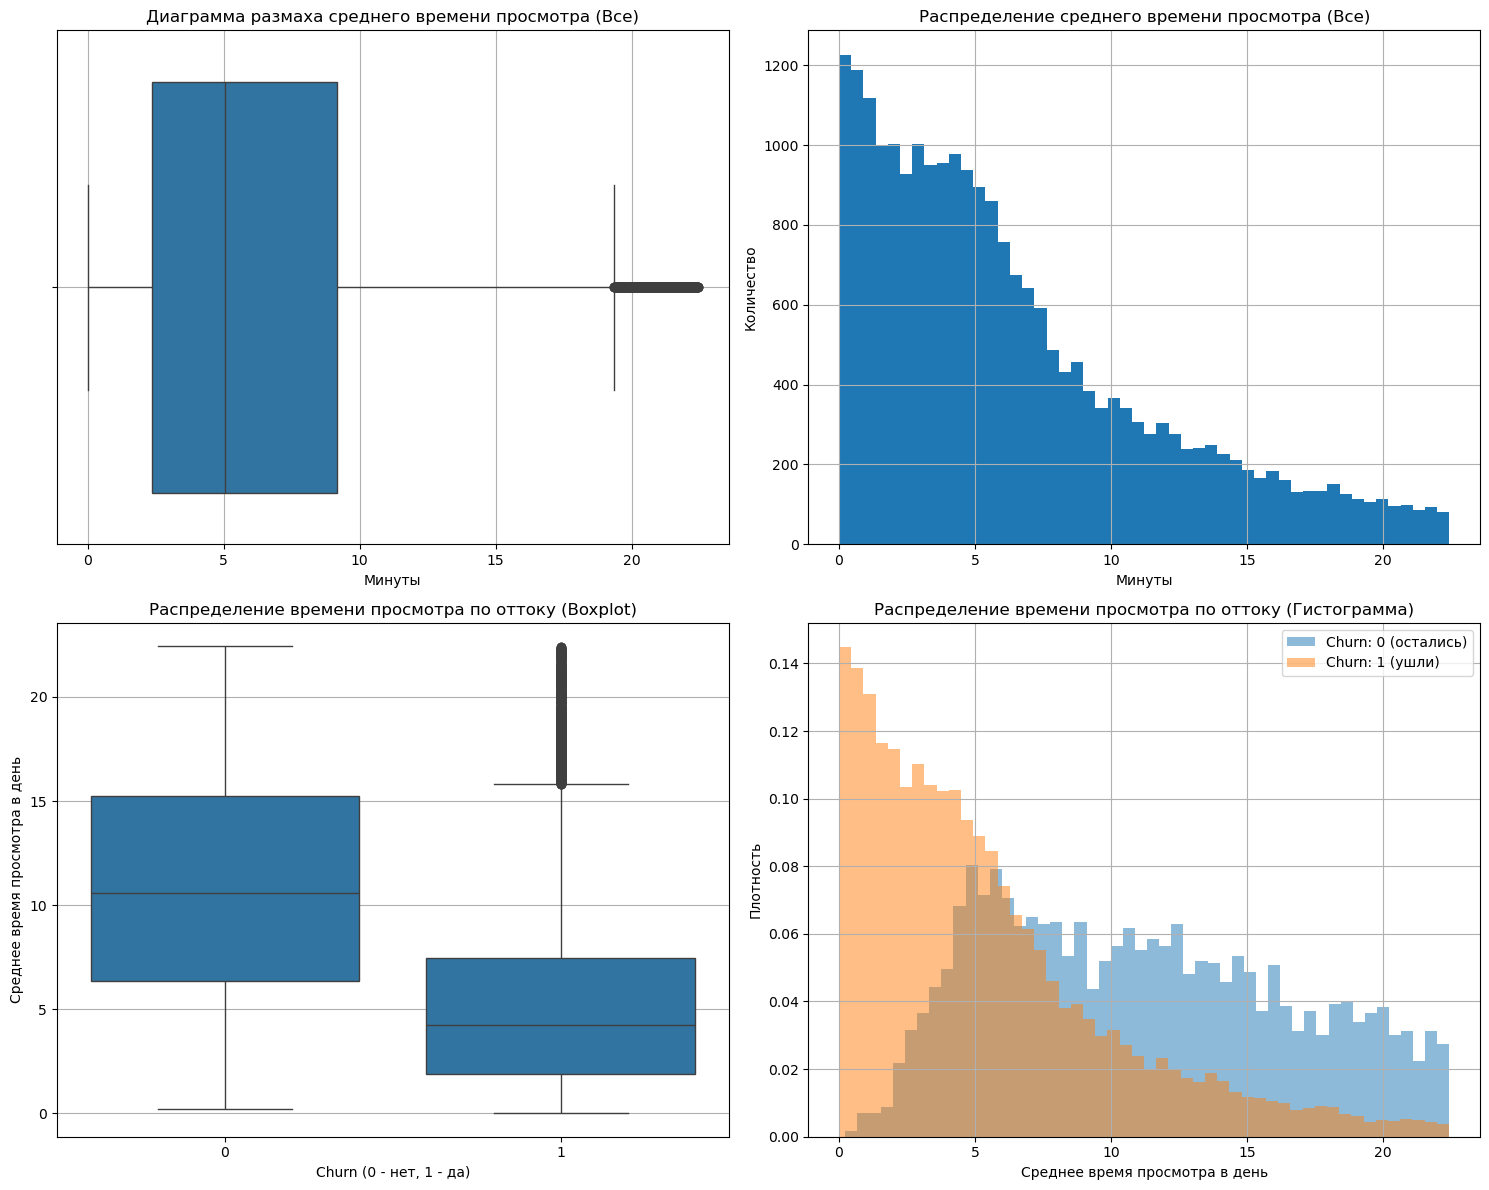

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12), gridspec_kw={'width_ratios': [1, 1]}) 

ax1 = axes[0, 0]  # Верхний левый
ax2 = axes[0, 1]  # Верхний правый
ax3 = axes[1, 0]  # Нижний левый
ax4 = axes[1, 1]  # Нижний правый

# 1. boxplot: ОБЩЕЕ распределение avg_min_watch_daily (без учета churn)
sns.boxplot(x=df['avg_min_watch_daily'], ax=ax1) # Используем ax1
ax1.set_title('Диаграмма размаха среднего времени просмотра (Все)')
ax1.set_xlabel('Минуты')
ax1.set_ylabel('') # Ящик с усами по умолчанию использует Y для размаха, X для значений
ax1.grid(True)

# 2. Гистограмма: ОБЩЕЕ распределение avg_min_watch_daily (без учета churn)
ax2.hist(df['avg_min_watch_daily'], bins=50)
ax2.set_title('Распределение среднего времени просмотра (Все)')
ax2.set_xlabel('Минуты')
ax2.set_ylabel('Количество')
ax2.grid(True)

# 3. boxplot: avg_min_watch_daily в разрезе churn
sns.boxplot(data=df, x='churn', y='avg_min_watch_daily', ax=ax3) # Используем ax3
ax3.set_title('Распределение времени просмотра по оттоку (Boxplot)')
ax3.set_xlabel('Churn (0 - нет, 1 - да)')
ax3.set_ylabel('Среднее время просмотра в день')
ax3.grid(True, axis='y')

# 4. Гистограмма: avg_min_watch_daily в разрезе churn (наложение)
churn_0_data = df[df['churn'] == 0]['avg_min_watch_daily']
churn_1_data = df[df['churn'] == 1]['avg_min_watch_daily']

ax4.hist(churn_0_data, bins=50, alpha=0.5, label='Churn: 0 (остались)', density=True)
ax4.hist(churn_1_data, bins=50, alpha=0.5, label='Churn: 1 (ушли)', density=True)
ax4.set_title('Распределение времени просмотра по оттоку (Гистограмма)')
ax4.set_xlabel('Среднее время просмотра в день')
ax4.set_ylabel('Плотность')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

> видим что у отточной категории медиана среднего времени просомтра в 2 раза меньше в сравнении с теми, кто купил подсписку - 5 минут  
> среди тех, у кого среднее время более 8 минуты большинство купили подписку

#### `number_of_days_logged`

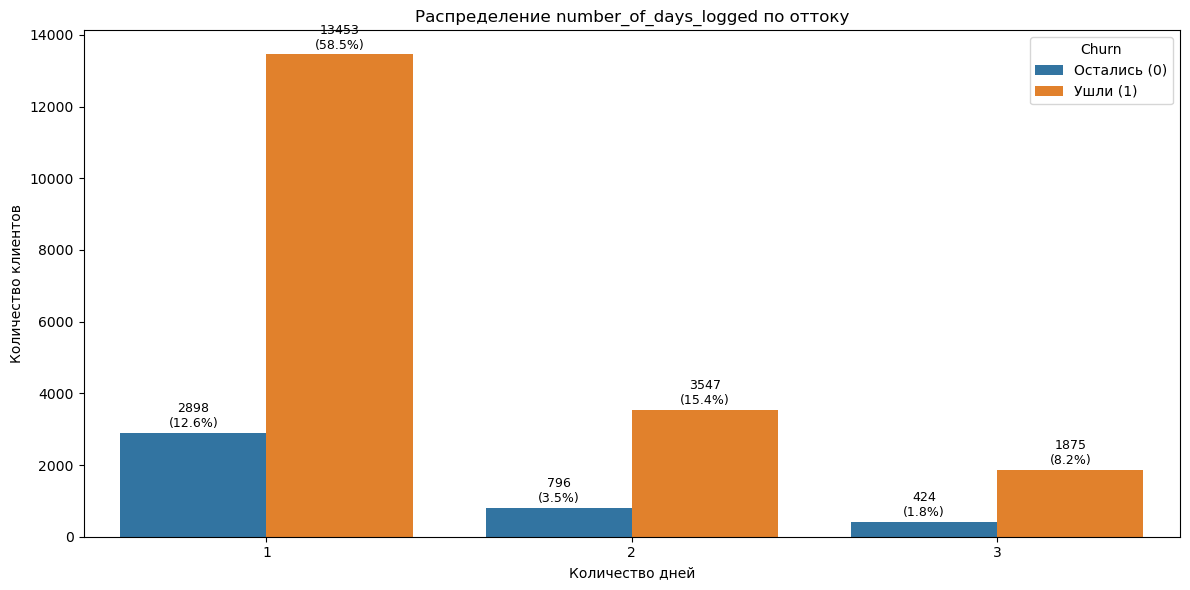

In [42]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='number_of_days_logged', hue='churn', data=df)

plt.title('Распределение number_of_days_logged по оттоку')
plt.xlabel('Количество дней')
plt.ylabel('Количество клиентов')
plt.legend(title='Churn', labels=['Остались (0)', 'Ушли (1)']) 

# Добавляем аннотации (значения и проценты)
# Общее количество строк для расчета общего процента
total_count = len(df)

# Проходим по всем патчам (столбцам)
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Не аннотируем пустые столбцы
        percentage = (height / total_count) * 100
        ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 2), textcoords='offset points', fontsize=9)

plt.tight_layout() 
plt.show()

#### `start_trial_date`

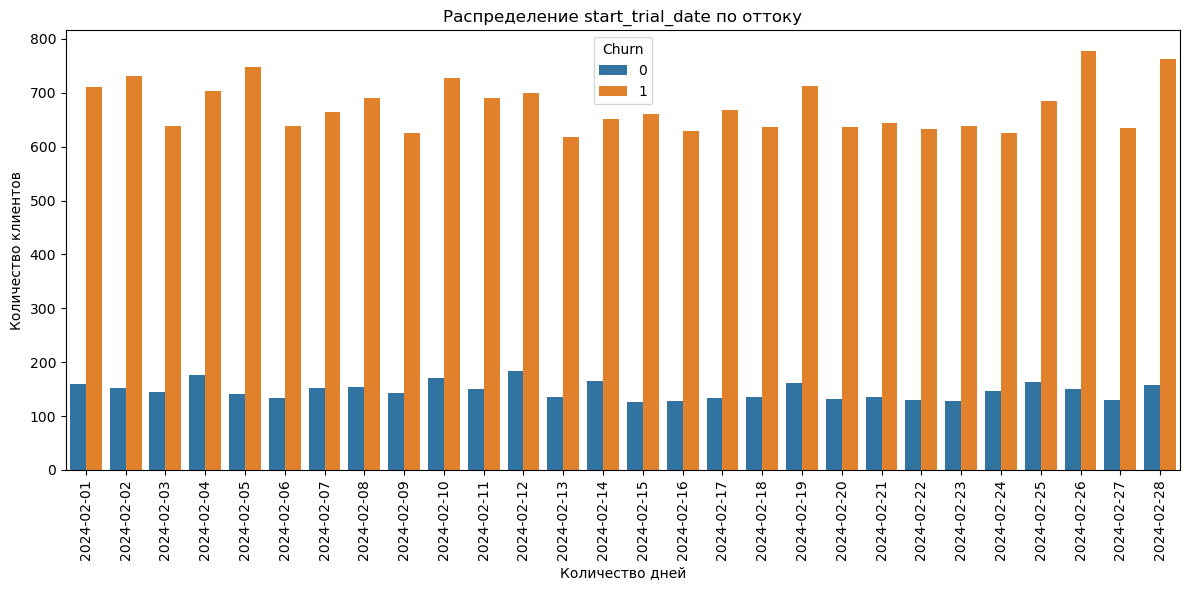

In [44]:
plt.figure(figsize=(12, 6))
sns.countplot(x='start_trial_date', hue='churn', data=df)

plt.title('Распределение start_trial_date по оттоку')
plt.xlabel('Количество дней')
plt.ylabel('Количество клиентов')
plt.legend(title='Churn')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

> влияние даты начала на триальный период не выявлено, активность по дня примерно равномерная с небольшими вспелексами в выходные

#### `city`

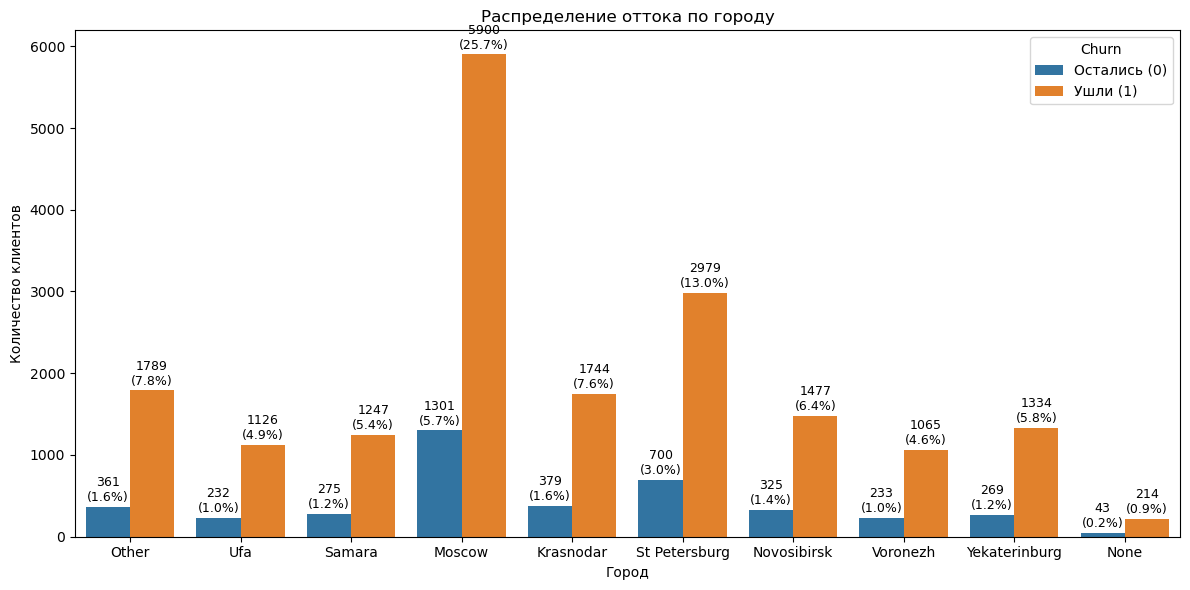

In [47]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='city', hue='churn', data=df)

plt.title('Распределение оттока по городу')
plt.xlabel('Город')
plt.ylabel('Количество клиентов')
plt.legend(title='Churn', labels=['Остались (0)', 'Ушли (1)']) 

# Общее количество строк для расчета общего процента
total_count = len(df)

# Проходим по всем патчам (столбцам)
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Не аннотируем пустые столбцы
        percentage = (height / total_count) * 100
        ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 2), textcoords='offset points', fontsize=9)

plt.tight_layout() 
plt.show()

> на первый взгляд влияение города незначительно на отток, однако Москва и СПБ - самые большие когорты клиентов

#### `device`

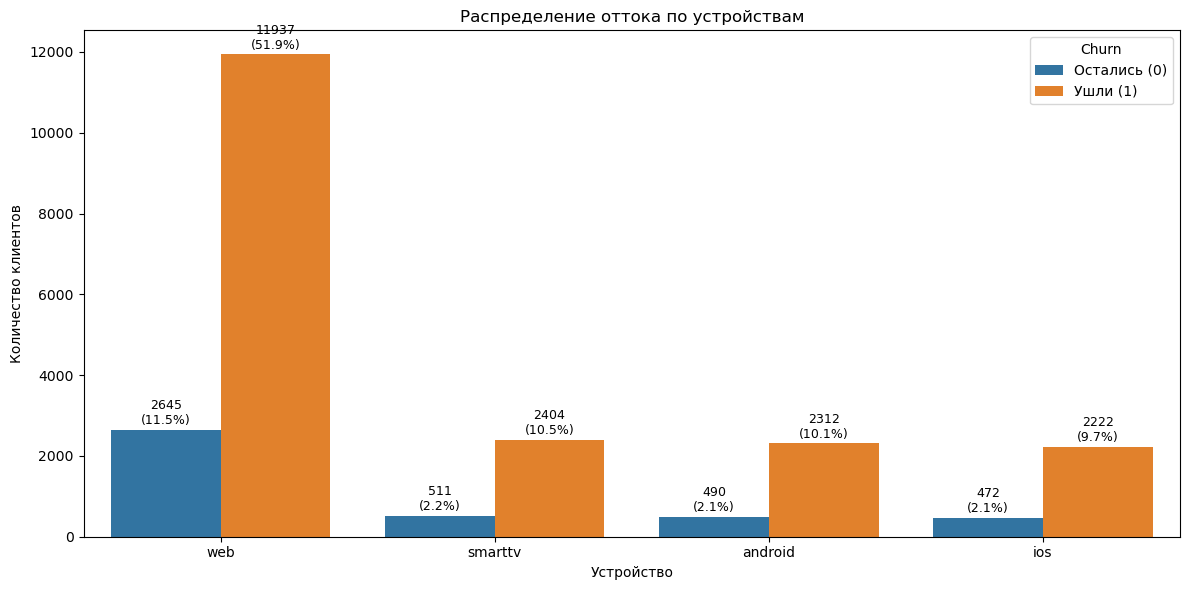

In [50]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='device', hue='churn', data=df)

plt.title('Распределение оттока по устройствам')
plt.xlabel('Устройство')
plt.ylabel('Количество клиентов')
plt.legend(title='Churn', labels=['Остались (0)', 'Ушли (1)']) 

total_count = len(df)

for p in ax.patches:
    height = p.get_height()
    if height > 0:  
        percentage = (height / total_count) * 100
        ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 2), textcoords='offset points', fontsize=9)

plt.tight_layout() 
plt.show()

> визуально влияние устройства и оттока не прослеживается, но большая часть - это web

#### `source`	

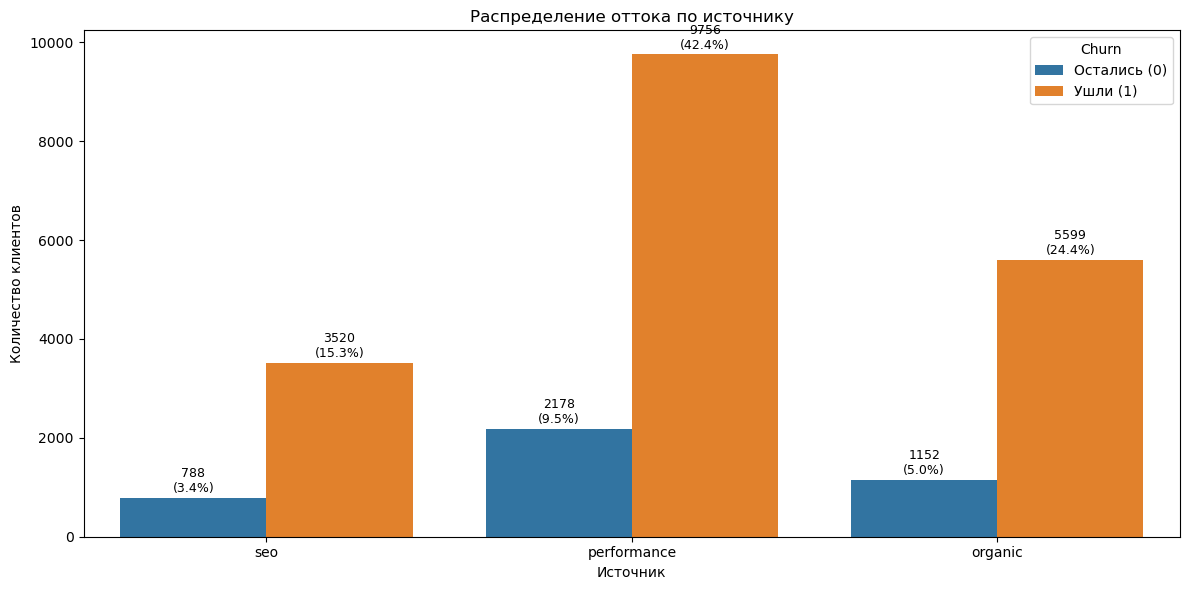

In [53]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='source', hue='churn', data=df)

plt.title('Распределение оттока по источнику')
plt.xlabel('Источник')
plt.ylabel('Количество клиентов')
plt.legend(title='Churn', labels=['Остались (0)', 'Ушли (1)']) 

total_count = len(df)

for p in ax.patches:
    height = p.get_height()
    if height > 0:  
        percentage = (height / total_count) * 100
        ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 2), textcoords='offset points', fontsize=9)

plt.tight_layout() 
plt.show()

> влияние источника на отток не прослеживается

#### `favourite_genre`

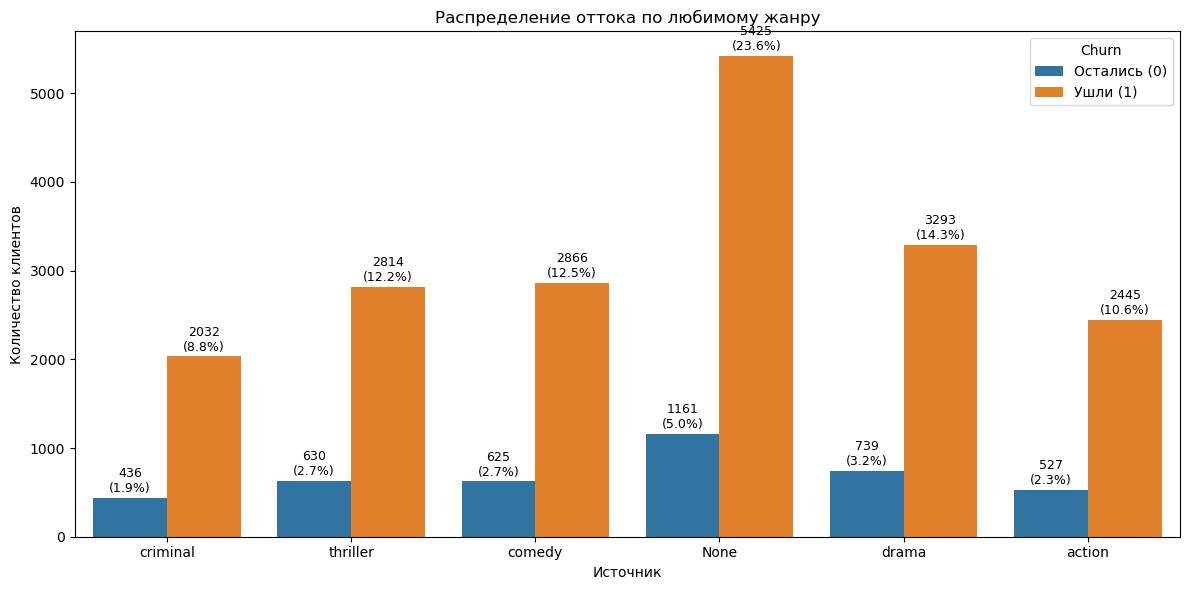

In [56]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='favourite_genre', hue='churn', data=df)

plt.title('Распределение оттока по любимому жанру')
plt.xlabel('Источник')
plt.ylabel('Количество клиентов')
plt.legend(title='Churn', labels=['Остались (0)', 'Ушли (1)']) 

total_count = len(df)

for p in ax.patches:
    height = p.get_height()
    if height > 0:  
        percentage = (height / total_count) * 100
        ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 2), textcoords='offset points', fontsize=9)

plt.tight_layout() 
plt.show()

> - визуально можно отследить, что среди тех кто не указал любимый жанр - наибольшая категория оттока
> - при этом стоит также оценить корреляцию неуказания жанра и времени проведённого на сервисе, возможно человек ушёл, даже не успев воспользоваться, изучим это в след пункте

#### Дополнительная оценка корреляции

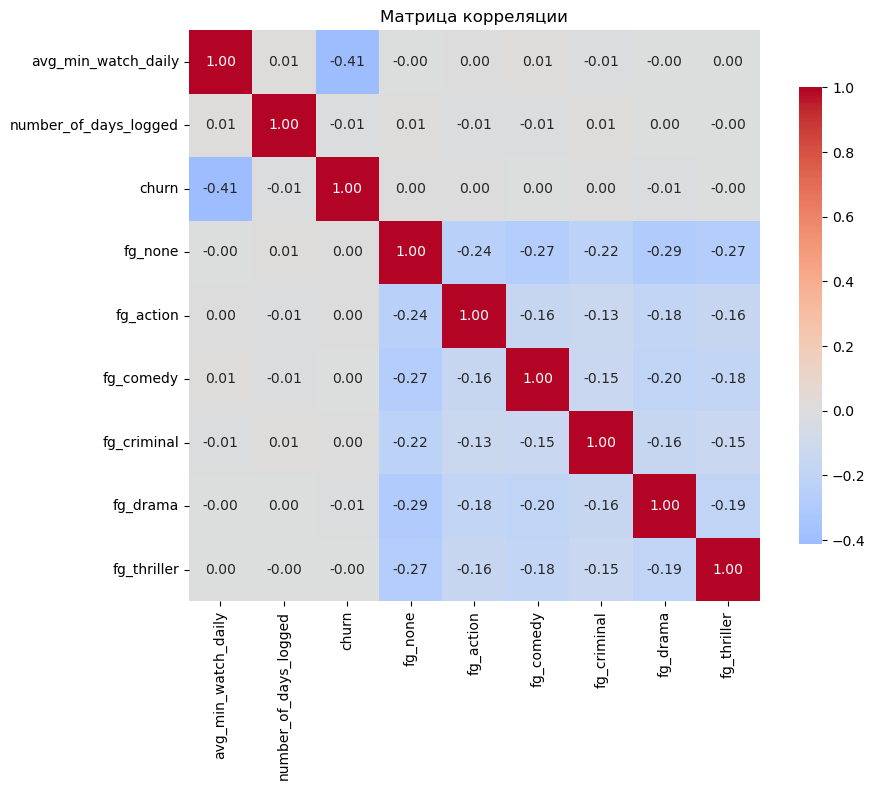

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_correlate = [
    'avg_min_watch_daily',
    'number_of_days_logged',
    'churn',
    'fg_none', 
    'fg_action',
    'fg_comedy',
    'fg_criminal',
    'fg_drama',
    'fg_thriller'
]

# Создаем подмножество DataFrame
df_subset = df[columns_to_correlate]

# Рассчитываем матрицу корреляции
correlation_matrix = df_subset.corr()

# Визуализируем
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={"shrink": .8}
)
plt.title('Матрица корреляции')
plt.tight_layout()
plt.show()

> нет, всё же значимой корреляции между неуказанием жанра и временем проведённым на сервисе не удаётся найти

## Feature Engineering

In [62]:
import pandas as pd

# активен более 1 дня
df['is_active_more_than_1day'] = (df['number_of_days_logged'] > 1).astype(int)

# уровень активности (например, 1 день, 2-3 дня, 4-7 дней)
def categorize_activity(days):
    if days == 1:
        return '1'
    elif 2 <= days <= 3:
        return '2-3'
    elif 4 <= days <= 7:
        return '4-7'
    else:
        return '>7'
df['activity_level'] = df['number_of_days_logged'].apply(categorize_activity)

# плотность просмотра (суммарное время) 
df['total_watch_time'] = df['avg_min_watch_daily'] * df['number_of_days_logged']

# день недели начала пробного периода
df['trial_start_day_of_week'] = pd.to_datetime(df['start_trial_date']).dt.dayofweek

# бинарный признак для дня недели (например, выходной)
df['is_weekend'] = df['trial_start_day_of_week'].isin([6, 7]).astype(int)

# просмотр новых признаков
display(df[['is_active_more_than_1day', 'activity_level', 'total_watch_time', 'trial_start_day_of_week', 'is_weekend']].sample(10))

,is_active_more_than_1day,activity_level,total_watch_time,trial_start_day_of_week,is_weekend
5121,0,1,5.234008,0,0
21005,0,1,2.143774,2,0
11339,1,2-3,13.373520,0,0
8458,0,1,11.486704,4,0
2952,0,1,3.034259,5,0
12336,1,2-3,42.076945,1,0
13190,1,2-3,11.334785,1,0
12206,1,2-3,34.359466,0,0
13881,0,1,10.670881,2,0
8098,0,1,2.111417,3,0


# Гипотезы

## Формулировка гипотез о влиянии атрибутов на конверсию

### **1. Влияние среднего времени просмотра (`avg_min_watch_daily`)**

Нулевая гипотеза $H_0$: среднее время просмотра не влияет на конверсию в покупку

Альтернативная гипотеза $H_1$: чем больше среднее время просмотра, тем больше вероятность покупки.

### **2. Влияние количества активных дней (`number_of_days_logged`)**

Нулевая гипотеза $H_0$: количество активных дней не влияет на конверсию в покупку

Альтернативная гипотеза $H_1$: чем больше количеством активных дней, тем больше вероятность конверсии в покупки


### **3. Влияние города регистрации (`city`)**

Нулевая гипотеза $H_0$: город регистрации не влияет на конверсию в покупку

Альтернативная гипотеза $H_1$: существует статистически значимая связь между городом регистрации и конверсией в покупку

### **4. Влияние устройства регистрации (`device`)**

Нулевая гипотеза $H_0$: устройство регистрации не влияет на конверсию в покупку

Альтернативная гипотеза $H_1$: существует статистически значимая связь между устройством регистрации и конверсией в покупку

### **5. Влияние источника трафика (`source`)**

Нулевая гипотеза $H_0$: источник трафика не влияет на конверсию в покупку

Альтернативная гипотеза $H_1$: существует статистически значимая связь между источником трафика и конверсией в покупку

### **6. Влияние любимого жанра (`favourite_genre`)**

Нулевая гипотеза $H_0$: любимый жанр пользователя не влияет на конверсию в покупку

Альтернативная гипотеза $H_1$: существует статистически значимая связь между любимымым жанром пользователя и конверсией в покупку

### **7. Влияние самого факта указания жанра**

Нулевая гипотеза $H_0$: факт указания любимого жанра пользователя не влияет на конверсию в покупку

Альтернативная гипотеза $H_1$: существует статистически значимая связь между фактом указания любимого жанра и конверсией в покупку

### **8. Влияние даты начала пробного периода (`start_trial_date`)**

Нулевая гипотеза $H_0$: дата начала пробного периода не влияет на конверсию в покупку

Альтернативная гипотеза $H_1$: существует статистически значимая связь между датой начала пробного периода и конверсией в покупку

## План статистической проверки гипотез

После формулировки гипотез необходимо определить корректные методы их проверки.  
Выбор теста зависит от типа признака (числовой / категориальный) и распределения данных.

---

### **1. Проверка влияния среднего времени просмотра (`avg_min_watch_daily`)**

Тип признака: числовой (непрерывный).  
Тип ответа: бинарный (0/1).

**Инструменты проверки:**

1. **Корреляция Пирсона между `avg_min_watch_daily` и `conversion`**  
   - Проверяет линейную связь между признаками.  
   - Значимое отклонение коэффициента от 0 → основание отвергнуть $H_0$.

2. **Квантильный анализ конверсии**  
   - Разбиваем пользователей на группы по времени просмотра.  
   - Если конверсия изменяется монотонно → свидетельство влияния.

3. **Тест разницы долей между квантилями (z-test proportion)**  
   - Проверяет, различаются ли конверсии между низкими и высокими квантилями.

---

### **2. Проверка влияния числа активных дней (`number_of_days_logged`)**

Тип признака: числовой, дискретный.

**Инструменты:**

1. **Корреляция Пирсона между `number_of_days_logged` и `conversion`**.  
2. **Сравнение конверсии между значениями (например, 1 vs 7 дней) с помощью z-test пропорций**.  
3. **Логистическая регрессия** (в расширенном исследовании).

---

### **3. Проверка влияния города (`city`)**

Тип признака: категориальный, >2 значений.

**Инструмент:**  
**Хи-квадрат тест независимости (χ² test of independence)**.

- Строим таблицу сопряжённости `city × conversion`.  
- Вычисляем χ² и p-value.  
- Если $p < \alpha$ → отклоняем $H_0$.

---

### **4. Проверка влияния устройства (`device`)**

Тип: категориальный, малое количество значений.

**Инструмент:**  
**Хи-квадрат тест независимости.**

Применение аналогично проверке по городу.

---

### **5. Проверка влияния источника трафика (`source`)**

Тип: категориальный.

**Инструмент:**
- **Хи-квадрат тест независимости.**
- При необходимости — post-hoc тесты для парных сравнений долей.

---

### **6. Проверка влияния жанра (`favourite_genre`)**

Тип: категориальный, много уровней, много пропусков.

**Инструменты:**

1. **Хи-квадрат тест независимости** — сравнение распределений.  
2. **Анализ пропусков как отдельной категории**:
   - создаём признак `genre_filled` (0/1),  
   - сравниваем конверсию через z-test разницы долей.

---

### **7. Проверка влияния факта указания жанра**

Тип: бинарный (жанр указан / не указан).

**Инструмент:**  
**z-test пропорций (test for difference in proportions)**.

Проверяет равенство двух вероятностей:
$$
P(Y=1 \mid Z=1) \quad \text{vs} \quad P(Y=1 \mid Z=0).
$$

---

### **8. Проверка влияния даты старта триала (`start_trial_date`)**

Тип: временной (дата → когорта).

**Инструменты:**

1. **Группировка по неделям или дням → χ² тест между когортами**.  
2. **Проверка тренда**  
   если даты упорядочены.

---

### **Итоговый план**

Каждый признак будет проверен статистически корректным методом:

| Признак                    | Тип           | Метод проверки                              |
|----------------------------|---------------|----------------------------------------------|
| avg_min_watch_daily        | числовой      | Пирсон, квантильный анализ, z-test           |
| number_of_days_logged      | числовой      | Пирсон, сравнение долей                      |
| city                       | категориальный| χ² тест                                      |
| device                     | категориальный| χ² тест                                      |
| source                     | категориальный| χ² тест                                      |
| favourite_genre            | категориальный| χ² тест                                      |
| genre_filled (0/1)         | бинарный      | z-test пропорций                             |
| start_trial_date (когорты) | временной     | χ² по когортам                               |

Все выводы будут формулироваться через p-value при уровне значимости  
$$
\alpha = 0.05.
$$

## Гипотеза 1. Влияние среднего времени просмотра (`avg_min_watch_daily`) на конверсию

**Цель:** проверить, зависит ли вероятность покупки подписки от среднего времени просмотра в день на триале.

Проверку будем проводить в несколько шагов:

1. Рассчитаем корреляцию между `avg_min_watch_daily` и `conversion`.
2. Разобьём пользователей на квантили по `avg_min_watch_daily` и сравним конверсии.
3. Визуализируем зависимость.

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv("videostreaming_platform.csv")

# Создаем бинарный признак конверсии: 1 = купил, 0 = не купил
df["conversion"] = 1 - df["churn"]

df[["avg_min_watch_daily", "conversion"]].head()

,avg_min_watch_daily,conversion
0,2.076642,0
1,5.101392,0
2,2.906597,0
3,2.702388,1
4,10.237305,0


### 1. Корреляция Пирсона между `avg_min_watch_daily` и `conversion`

Так как `conversion` — бинарная переменная (0/1), а `avg_min_watch_daily` — числовая, коэффициент корреляции Пирсона: $\rho = \operatorname{corr}(X, Y)$


будет совпадать с бисериальной корреляцией и является корректной мерой линейной связи между временем просмотра и вероятностью покупки.

In [77]:
corr_watch_conv = df["avg_min_watch_daily"].corr(df["conversion"])
print(f"Корреляция Пирсона между avg_min_watch_daily и conversion: {corr_watch_conv:.3f}")

Корреляция Пирсона между avg_min_watch_daily и conversion: 0.472


Полученное значение корреляции Пирсона примерно: $\rho \approx 0.47.$

**Интерпретация:**

- Знак **положительный**: чем больше среднее время просмотра, тем выше вероятность покупки подписки.
- Модуль $|\rho| \approx 0.47$ — это **умеренно сильная линейная связь** для поведенческих данных.

Этого уже достаточно, чтобы отвергнуть $H_0$ в пользу $H_1$ на качественном уровне, но дополним анализ квантильным разбиением.


### 2. Квантильный анализ конверсии по `avg_min_watch_daily`

Чтобы увидеть форму зависимости (линейная она или нелинейная, монотонная или нет),  
разобьём пользователей на 5 квантилей по `avg_min_watch_daily` и посчитаем конверсию в каждом квантиле:  
$\text{conversion\_rate}_q = P(Y = 1 \mid X \in \text{квантиль } q).$

In [80]:
df["watch_quantile"] = pd.qcut(
    df["avg_min_watch_daily"],
    q=5,
    duplicates="drop" 
)

quantile_summary = (
    df
    .groupby("watch_quantile", observed=True)
    .agg(
        users=("user_id", "count"),
        avg_watch=("avg_min_watch_daily", "mean"),
        conversion_rate=("conversion", "mean")
    )
)

quantile_summary

,users,avg_watch,conversion_rate
watch_quantile,,,
"(-0.0008190000000000001, 1.957]",5600,0.927082,0.008929
"(1.957, 4.238]",5600,3.094240,0.070536
"(4.238, 6.878]",5600,5.462407,0.163571
"(6.878, 12.34]",5600,9.206718,0.269286
"(12.34, 80.072]",5600,20.372867,0.541250


В таблице:

- `users` — число пользователей в квантиле,
- `avg_watch` — среднее время просмотра внутри квантиля,
- `conversion_rate` — доля пользователей, купивших подписку.

Если `conversion_rate` заметно растёт от нижнего квантиля к верхнему, это свидетельствует о сильной зависимости конверсии от времени просмотра.

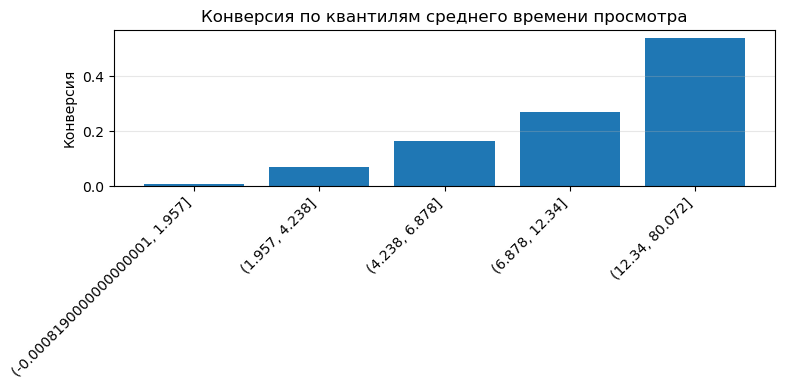

In [82]:
conversion_by_quantile = quantile_summary["conversion_rate"]

plt.figure(figsize=(8, 4))
plt.bar(range(len(conversion_by_quantile)),
        conversion_by_quantile.values)

plt.xticks(
    range(len(conversion_by_quantile)),
    [str(i) for i in conversion_by_quantile.index],
    rotation=45,
    ha="right"
)

plt.ylabel("Конверсия")
plt.title("Конверсия по квантилям среднего времени просмотра")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Вывод по Гипотезе 1

1. Коэффициент корреляции Пирсона между `avg_min_watch_daily` и `conversion`: $\rho \approx 0.47$,
   что указывает на умеренно сильную положительную линейную связь.

2. Квантильный анализ показывает, что конверсия **монотонно растёт** от нижнего квантиля по времени просмотра к верхнему.  
   В нижнем квантиле конверсия близка к нулю, в верхнем — превышает 50%.

3. Таким образом, мы **отвергаем нулевую гипотезу $H_0$** о независимости конверсии от среднего времени просмотра  
и принимаем альтернативную гипотезу $H_1$: $P(Y = 1 \mid X = x) \text{ существенно зависит от } x.$

**Среднее время просмотра в день является сильным предиктором конверсии** и ключевым поведенческим атрибутом для дальнейшего моделирования и принятия решений.

## Гипотеза 2. Влияние количества активных дней (`number_of_days_logged`) на конверсию

**Цель:** оценить, меняется ли вероятность покупки подписки в зависимости от того, в сколькие дни пользователь заходил на платформу в течение триального периода.

Обозначения:

- $X_2 = \text{number\_of\_days\_logged} \in \{1,2,\dots,7\}$
- $Y = \text{conversion} \in \{0,1\}$

**Нулевая гипотеза $H_0$:**
$$
P(Y = 1 \mid X_2 = k) = p_0 \quad \text{для всех } k.
$$

**Альтернативная гипотеза $H_1$:**
$$
\exists k_1, k_2:\; P(Y = 1 \mid X_2 = k_1) \neq P(Y = 1 \mid X_2 = k_2).
$$

Проверку выполним с помощью:
1. Корреляции Пирсона между числом активных дней и конверсией.
2. Сравнения конверсии между различными значениями `number_of_days_logged`.
3. Визуального анализа зависимости.

In [85]:
import pandas as pd

# загрузка данных
df = pd.read_csv("videostreaming_platform.csv")
df["conversion"] = 1 - df["churn"]

# корреляция Пирсона
corr_days_conv = df["number_of_days_logged"].corr(df["conversion"])

# средняя конверсия по числу активных дней
conv_by_days = df.groupby("number_of_days_logged", observed=True)["conversion"].mean()

corr_days_conv, conv_by_days

(0.01255532930050953,
 number_of_days_logged
 1    0.207200
 2    0.214069
 3    0.211823
 4    0.224903
 5    0.204365
 6    0.242481
 7    0.212185
 Name: conversion, dtype: float64)

### 1. Корреляция

Коэффициент Пирсона:
$$
\rho \approx 0.0126.
$$

Это **очень слабая** положительная связь (по сути, отсутствие линейной зависимости).

---

### 2. Конверсия по числу активных дней

Значения колеблются в узком диапазоне:
- от ~0.204 до ~0.242,
- без явной монотонности.

Конверсия во многом случайна и НЕ демонстрирует стабильного роста с увеличением `number_of_days_logged`.

На первый взгляд, это свидетельствует в пользу **нулевой гипотезы $H_0$**.

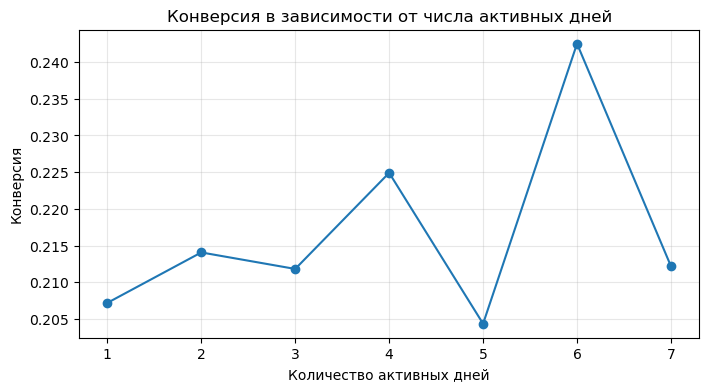

In [87]:
plt.figure(figsize=(8,4))
plt.plot(conv_by_days.index, conv_by_days.values, marker="o")

plt.xlabel("Количество активных дней")
plt.ylabel("Конверсия")
plt.title("Конверсия в зависимости от числа активных дней")
plt.grid(alpha=0.3)
plt.show()

### Вывод по Гипотезе 2

- Корреляция между `number_of_days_logged` и `conversion` составляет:
  $$
  \rho \approx 0.0126,
  $$
  что статистически является **нулевой связью**.

- График и групповые средние показывают, что конверсия колеблется в небольшом диапазоне (20–24%) и **не демонстрирует систематической зависимости** от числа активных дней.

- В отличие от среднего времени просмотра (`avg_min_watch_daily`), данная метрика **не является предиктором покупок**.

**Решение по гипотезе:**
- У нас **нет оснований отвергать $H_0$**.
- Количество дней, в которые пользователь логинился, **не влияет существенно на вероятность покупки подписки**.

## Гипотеза 3. Влияние города регистрации (`city`) на конверсию

**Цель:** определить, различается ли вероятность покупки подписки между пользователями из разных городов.

Пусть $C_1 = \text{city}$ — категориальная переменная.

**Нулевая гипотеза $H_0$:**
$$
P(Y = 1 \mid C_1 = c_i) = P(Y = 1 \mid C_1 = c_j) \quad 
\text{для всех } i, j.
$$

То есть город **не влияет** на вероятность покупки подписки.

**Альтернативная гипотеза $H_1$:**
$$
\exists\, c_i, c_j:\; P(Y = 1 \mid C_1 = c_i) \neq P(Y = 1 \mid C_1 = c_j).
$$

То есть хотя бы два города отличаются по конверсии.

Так как переменная категориальная, а отклик бинарный, используем:

- таблицу сопряжённости `city × conversion`,
- **хи-квадрат тест независимости (χ²)**.

In [90]:
df["conversion"] = 1 - df["churn"]

# строим таблицу частот
contingency_city = pd.crosstab(df["city"], df["conversion"])
contingency_city

conversion,0,1
city,,
Krasnodar,2033,542
Moscow,6874,1862
Novosibirsk,1738,475
Other,2130,530
Samara,1471,405
St Petersburg,3494,986
Ufa,1325,327
Voronezh,1234,334
Yekaterinburg,1558,374


### Наблюдаемая таблица частот

Таблица показывает, сколько пользователей купили и не купили подписку в каждом городе.
Эти данные являются основой для χ²-теста.

Далее сравним наблюдаемые частоты с ожидаемыми при условии независимости города и конверсии.

In [92]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_city)

chi2, p_value, dof

(10.367107129997025, 0.24019907845997027, 8)

### Результат χ² теста

Получено:

- Статистика χ² ≈ 10.37
- Степени свободы: 8
- p-value ≈ 0.24

Порог значимости: $\alpha = 0.05$.

Так как: $p = 0.24 \gg 0.05$,

мы **не отвергаем нулевую гипотезу $H_0$**.

---

### Что это означает?

- Различия в конверсии между городами **не являются статистически значимыми**.
- Наблюдаемые колебания (19–22%) укладываются в рамки случайного шума.
- Город регистрации **не является предиктором покупок**.
- Продуктовые, маркетинговые и таргетинговые решения **не должны опираться на город**.

---

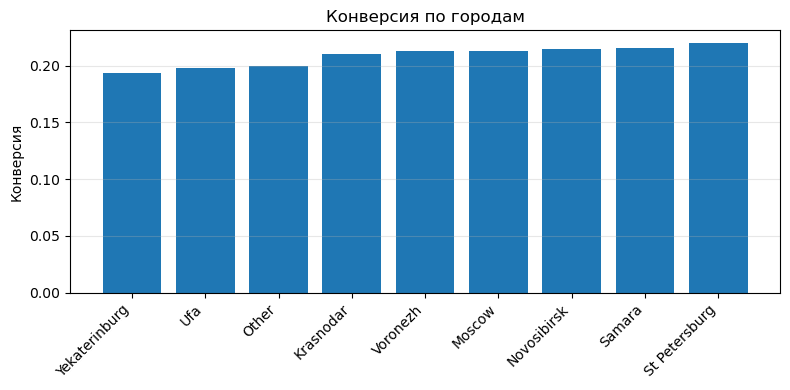

In [94]:
conv_by_city = df.groupby("city")["conversion"].mean().sort_values()

plt.figure(figsize=(8,4))
plt.bar(conv_by_city.index, conv_by_city.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Конверсия")
plt.title("Конверсия по городам")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Итог по Гипотезе 3

- χ² тест показал отсутствие статистически значимых различий конверсии между городами.
- Разброс конверсий минимален и объясняется случайной вариацией.
- Город не является фактором, влияющим на покупку подписки.

**Вывод:**  
Мы не находим оснований отвергнуть $H_0$.  
Город регистрации пользователя **не влияет** на вероятность покупки подписки.

## Гипотеза 4. Влияние устройства регистрации (`device`) на конверсию

**Цель:** определить, различается ли вероятность покупки подписки между пользователями,
которые зарегистрировались с разных устройств (web, android, ios, smarttv).

Пусть $C_2 = \text{device}$.

**Нулевая гипотеза $H_0$:** $P(Y = 1 \mid C_2 = d_i) = P(Y = 1 \mid C_2 = d_j)
\quad \text{для всех } i, j.$

То есть устройство регистрации **не влияет** на вероятность покупки.

**Альтернативная гипотеза $H_1$:** $\exists\, d_i, d_j:\; 
P(Y = 1 \mid C_2 = d_i) \neq P(Y = 1 \mid C_2 = d_j).$

Так как переменная категориальная, используем **хи-квадрат тест независимости (χ²)**.

In [97]:
# таблица сопряжённости device × conversion
contingency_device = pd.crosstab(df["device"], df["conversion"])
contingency_device

conversion,0,1
device,,
android,2686,730
ios,2596,680
smarttv,2831,725
web,13987,3765


Таблица показывает, сколько пользователей с каждого устройства купили / не купили подписку.
Эти наблюдаемые частоты будут сравниваться с ожидаемыми при независимости.

In [99]:
chi2_dev, p_dev, dof_dev, expected_dev = stats.chi2_contingency(contingency_device)

chi2_dev, p_dev, dof_dev

(1.5779382302843428, 0.6644024588395414, 3)

### Результаты χ² теста для признака `device`

- χ² $\approx$ 1.58
- p-value ≈ 0.66
- Уровень значимости: $\alpha = 0.05$

Так как: $p \gg 0.05,$

мы **не отвергаем нулевую гипотезу $H_0$**.

---

### Что это означает?

- Конверсия по устройствам различается незначительно.
- Наблюдаемые отличия объясняются случайными флуктуациями.
- Нет статистических доказательств, что устройство влияет на покупку.

Иными словами:

**Устройство регистрации не является значимым фактором конверсии.**

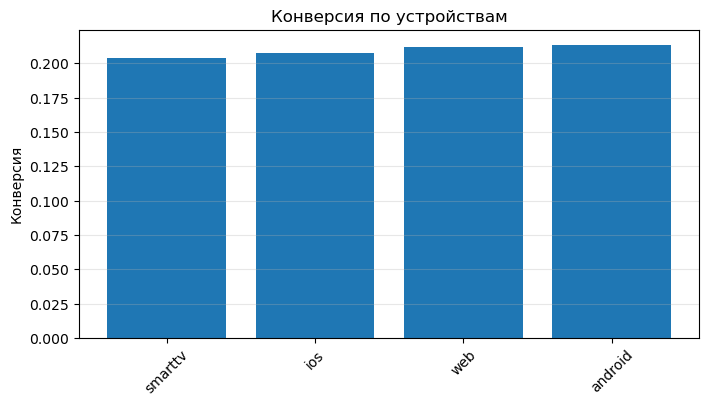

In [101]:
conv_by_device = df.groupby("device")["conversion"].mean().sort_values()

plt.figure(figsize=(8,4))
plt.bar(conv_by_device.index, conv_by_device.values)
plt.xticks(rotation=45)
plt.ylabel("Конверсия")
plt.title("Конверсия по устройствам")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Итог по Гипотезе 4

- χ² тест не выявил статистически значимых различий конверсии между устройствами.
- Визуальный анализ подтверждает, что конверсия лежит в узком диапазоне независимо от устройства.
- Метрика `device` не обладает предсказательной силой для объяснения покупок.

**Вывод:**  
Мы не находим оснований отвергнуть $H_0$.  
Устройство регистрации пользователя **не влияет** на вероятность покупки подписки.

## Гипотеза 5. Влияние источника трафика (`source`) на конверсию

**Цель:** проверить, различается ли вероятность покупки подписки между пользователями,
пришедшими из разных каналов:

- `performance`
- `seo`
- `organic`

Пусть $C_3 = \text{source}$.

**Нулевая гипотеза $H_0$:** $P(Y = 1 \mid C_3 = s_i) = P(Y = 1 \mid C_3 = s_j)
\quad \text{для всех } i,j.$

То есть источник трафика **не влияет** на вероятность покупки.

**Альтернативная гипотеза $H_1$:** $
\exists\, s_i, s_j:\; 
P(Y = 1 \mid C_3 = s_i) \neq P(Y = 1 \mid C_3 = s_j).$$

Так как переменная категориальная, используем **хи-квадрат тест независимости (χ²)**.

In [104]:
df = pd.read_csv("videostreaming_platform.csv")
df["conversion"] = 1 - df["churn"]

contingency_source = pd.crosstab(df["source"], df["conversion"])
contingency_source

conversion,0,1
source,,
organic,6527,1677
performance,11429,3111
seo,4144,1112


Таблица показывает распределение покупок и непокупок по источникам трафика.  
Эти наблюдаемые частоты сравниваются с ожидаемыми при условии независимости.

In [106]:
chi2_src, p_src, dof_src, expected_src = stats.chi2_contingency(contingency_source)

chi2_src, p_src, dof_src

(2.9038232286032892, 0.2341223084948606, 2)

### Результаты χ² теста для признака `source`

- χ² $\approx$ 2.9
- p-value ≈ 0.23
- dof = 2

Порог значимости: $\alpha = 0.05$.

Так как: $p \gg 0.05,$

мы **не отвергаем нулевую гипотезу $H_0$**.

---

### Интерпретация

- Конверсия почти одинакова для всех трёх каналов.
- Наблюдаемые колебания объясняются случайностью.
- Нет статистических доказательств, что `performance`, `seo` или `organic` дают разную конверсию.

**Источник трафика не является значимым фактором, определяющим покупку.**

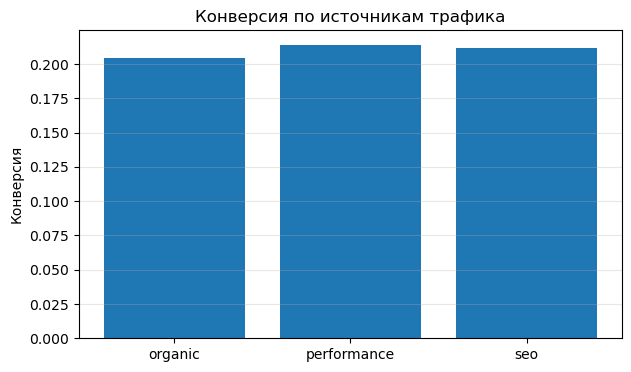

In [108]:
conv_by_source = df.groupby("source")["conversion"].mean()

plt.figure(figsize=(7,4))
plt.bar(conv_by_source.index, conv_by_source.values)
plt.ylabel("Конверсия")
plt.title("Конверсия по источникам трафика")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Итог по Гипотезе 5

- χ² тест не выявил статистически значимых различий конверсии между источниками трафика.
- Все каналы (`performance`, `seo`, `organic`) дают одинаковый уровень покупок.
- `source` не имеет прогностической ценности и не должен использоваться как сегмент для оптимизации воронки.

**Вывод:**  
Мы не находим оснований отвергнуть $H_0$.  
Источник трафика **не влияет** на вероятность покупки подписки.

## Гипотеза 6. Влияние выбранного жанра (`favourite_genre`) на конверсию

**Цель:** проверить, различается ли вероятность покупки подписки между пользователями,
которые указали разные любимые жанры при регистрации.

Пусть $C_4 = \text{favourite\_genre}$.

Жанров много: `drama`, `comedy`, `thriller`, `sci-fi`, `action`, `fantasy`, `noir`, и др.
Есть также значительная доля пропусков.

**Нулевая гипотеза $H_0$:** $P(Y = 1 \mid C_4 = g_i) = P(Y = 1 \mid C_4 = g_j)
\quad \text{для всех жанров } i,j.$

То есть выбранный жанр **не влияет** на вероятность покупки подписки.

**Альтернативная гипотеза $H_1$:** $
\exists\, g_i, g_j:\;
P(Y = 1 \mid C_4 = g_i) \neq P(Y = 1 \mid C_4 = g_j).
$

Так как признак категориальный с множеством уровней, используем:

- таблицу сопряжённости `favourite_genre × conversion`,
- **хи-квадрат тест независимости (χ²)**.

In [111]:
df = pd.read_csv("videostreaming_platform.csv")
df["conversion"] = 1 - df["churn"]

# заменим пропуски отдельной категорией
df["favourite_genre"] = df["favourite_genre"].fillna("unknown_genre")

# таблица сопряжённости
contingency_genre = pd.crosstab(df["favourite_genre"], df["conversion"])
contingency_genre

conversion,0,1
favourite_genre,,
action,2876,736
comedy,3379,905
criminal,2416,636
drama,3877,1051
thriller,3270,902
unknown_genre,6282,1670


В таблицу включена категория `unknown_genre` — пользователи, не указавшие жанр.

Это важно, потому что пропуск жанра может быть поведенческим паттерном,
а выбрасывать такие данные нельзя.

In [113]:
chi2_genre, p_genre, dof_genre, expected_genre = stats.chi2_contingency(contingency_genre)

chi2_genre, p_genre, dof_genre

(2.1286890736501847, 0.8310671792832605, 5)

### Результаты χ² теста для `favourite_genre`

- χ² $\approx$ 2.12
- p-value $\approx$ 0.83
- dof = 5

Порог значимости: $\alpha = 0.05.$

Так как обычно: $p > 0.05,$

мы **не отвергаем нулевую гипотезу $H_0$**.

---

### Интерпретация

- Различия в конверсии между жанрами незначимы.
- Выбор жанра — слабый поведенческий сигнал на этапе регистрации.
- Пользователи, выбирающие разные жанры, покупают подписку в среднем одинаково.
- Факт того, что жанра нет (`unknown_genre`), также не повышает и не снижает вероятность покупки.

Таким образом:

**Жанровые предпочтения при регистрации не влияют на покупку подписки.**

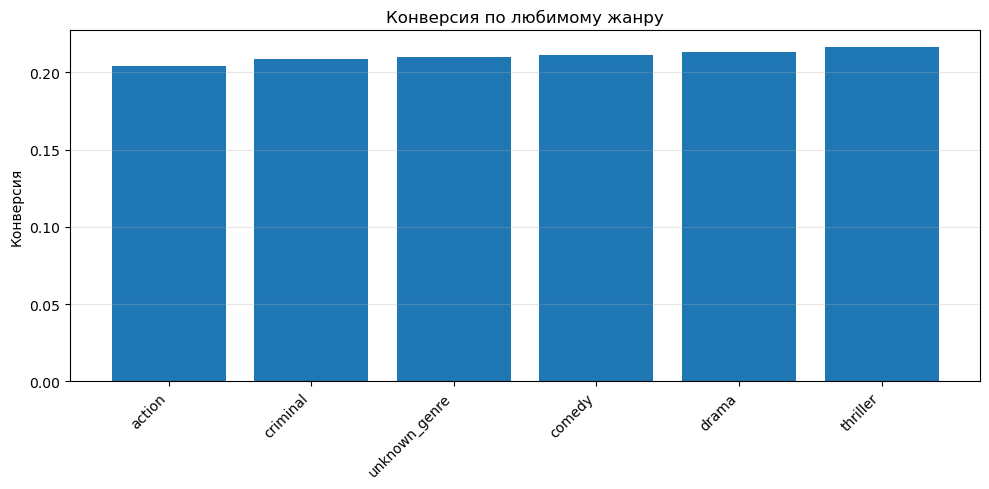

In [115]:
conv_by_genre = (
    df.groupby("favourite_genre")["conversion"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,5))
plt.bar(conv_by_genre.index, conv_by_genre.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Конверсия")
plt.title("Конверсия по любимому жанру")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Итог по Гипотезе 6

- χ² тест не выявил статистически значимых различий конверсии между жанрами.
- Визуальный анализ подтверждает минимальный разброс конверсии.
- Жанры отражают вкусы пользователя, но не его готовность платить на триале.

**Вывод:**  
Мы не находим оснований отвергнуть $H_0$.  
Любимый жанр, указанный при регистрации, **не влияет** на вероятность покупки подписки.

## Гипотеза 7. Влияние факта указания жанра (`favourite_genre`) на конверсию

**Цель:** выяснить, различается ли вероятность покупки подписки у пользователей,
которые заполнили любимый жанр, и тех, кто оставил поле пустым.

Пусть бинарная переменная:

$
Z =
\begin{cases}
1,& \text{если жанр указан}, \\
0,& \text{если жанр не указан}.
\end{cases}
$

**Нулевая гипотеза $H_0$:**
$
P(Y = 1 \mid Z = 1) = P(Y = 1 \mid Z = 0).
$

То есть факт указания жанра **не влияет** на вероятность покупки.

**Альтернативная гипотеза $H_1$:**
$
P(Y = 1 \mid Z = 1) \neq P(Y = 1 \mid Z = 0).
$

Так как сравниваются *две доли*, используем:

- **z-test для разницы пропорций**.

In [118]:
df = pd.read_csv("videostreaming_platform.csv")
df["conversion"] = 1 - df["churn"]

# бинарный признак факта заполнения жанра
df["genre_filled"] = df["favourite_genre"].notna().astype(int)

df[["favourite_genre", "genre_filled", "conversion"]].head(10)

,favourite_genre,genre_filled,conversion
0,drama,1,0
1,criminal,1,0
2,criminal,1,0
3,thriller,1,1
4,thriller,1,0
5,comedy,1,0
6,comedy,1,0
7,NaN,0,1
8,criminal,1,0
9,action,1,1


In [119]:
conv_filled = df[df["genre_filled"] == 1]["conversion"].mean()
conv_not_filled = df[df["genre_filled"] == 0]["conversion"].mean()

conv_filled, conv_not_filled

(0.21099361532322425, 0.21001006036217304)

### Средняя конверсия:

- Пользователи, указавшие жанр: **~21.1%**
- Пользователи без жанра: **~20.0%**

Разница составляет примерно **0.1 процентных пункта**, что визуально ничтожно мало.
Однако проверим статистическую значимость через z-test пропорций.

In [121]:
# количество оплат в обеих группах
success = [
    df.loc[df["genre_filled"] == 1, "conversion"].sum(),
    df.loc[df["genre_filled"] == 0, "conversion"].sum()
]

# размеры выборок
nobs = [
    df.loc[df["genre_filled"] == 1].shape[0],
    df.loc[df["genre_filled"] == 0].shape[0]
]

z_stat, p_val = proportions_ztest(success, nobs)
z_stat, p_val

(0.18198232901218325, 0.8555965937402933)

### Результат z-test пропорций

- Z-statistic $\approx$ 0.18
- p-value $\approx$ 0.86

Так как:
$
p > 0.05,
$

мы **не отвергаем нулевую гипотезу**.

---

### Интерпретация

- Конверсия пользователей, указавших жанр, и пользователей без жанра **не различается статистически значимо**.
- Хотя заполнение жанра отражает некоторую вовлечённость, она не влияет на готовность платить.

**Факт заполнения жанра не является фактором, влияющим на покупку подписки.**

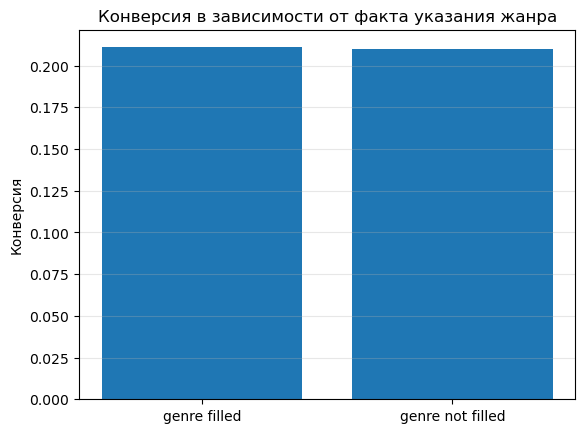

In [123]:
plt.bar(["genre filled", "genre not filled"], [conv_filled, conv_not_filled])
plt.ylabel("Конверсия")
plt.title("Конверсия в зависимости от факта указания жанра")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Итог по Гипотезе 7

- Разница конверсий между пользователями, указавшими жанр, и пользователями без указанного жанра составляет менее 0.5 п.п.
- z-test показывает отсутствие статистически значимых различий.
- Следовательно, этот атрибут **не имеет предсказательной ценности**.

**Вывод:**  
Мы не находим оснований отвергнуть $H_0$.  
Факт заполнения жанра **не влияет** на вероятность покупки подписки.

## Гипотеза 8. Влияние даты начала пробного периода (`start_trial_date`) на конверсию

**Цель:** проверить, различается ли вероятность покупки подписки между когортами пользователей,
которые начали триальный период в разные даты.

Пусть $C_5 = \text{start\_trial\_date}$, затем агрегируем даты в недельные когорты: $\text{cohort} = \text{week}(C_5).$

**Нулевая гипотеза $H_0$:** $P(Y = 1 \mid C_5 = t_i) = P(Y = 1 \mid C_5 = t_j)
\quad \text{для всех недель } i,j.$

То есть дата начала триала **не влияет** на вероятность покупки.

**Альтернативная гипотеза $H_1$:** $\exists\, t_i, t_j:\; P(Y = 1 \mid C_5 = t_i) \neq P(Y = 1 \mid C_5 = t_j).$

Так как признак категориальный (недельные группы), используем:

- таблицу сопряжённости `cohort × conversion`,
- **хи-квадрат тест независимости (χ²)**.

In [126]:
df = pd.read_csv("videostreaming_platform.csv")
df["conversion"] = 1 - df["churn"]

# приводим дату к datetime
df["start_trial_date"] = pd.to_datetime(df["start_trial_date"])

# создаём недельную когорту
df["cohort_week"] = df["start_trial_date"].dt.to_period("W").astype(str)

df[["start_trial_date", "cohort_week", "conversion"]].head()

,start_trial_date,cohort_week,conversion
0,2024-02-01,2024-01-29/2024-02-04,0
1,2024-02-01,2024-01-29/2024-02-04,0
2,2024-02-01,2024-01-29/2024-02-04,0
3,2024-02-01,2024-01-29/2024-02-04,1
4,2024-02-01,2024-01-29/2024-02-04,0


In [127]:
contingency_cohort = pd.crosstab(df["cohort_week"], df["conversion"])
contingency_cohort

conversion,0,1
cohort_week,,
2024-01-29/2024-02-04,3291,897
2024-02-05/2024-02-11,5543,1522
2024-02-12/2024-02-18,5350,1441
2024-02-19/2024-02-25,5396,1418
2024-02-26/2024-03-03,2520,622


Каждая строка — это когорта пользователей, которые начали триал в течение одной календарной недели.

Мы проверяем, отличаются ли их уровни конверсии.

In [129]:
chi2_cohort, p_cohort, dof_cohort, expected_cohort = stats.chi2_contingency(contingency_cohort)

chi2_cohort, p_cohort, dof_cohort

(4.687735609010138, 0.32086344793181676, 4)

### Результаты χ² теста для когорт по дате начала триала

- χ² $\approx$ 4.69
- p-value $\approx$ 0.32
- dof = 4

Порог: $\alpha = 0.05.$

Так как: $p > 0.05,$

мы **не отвергаем нулевую гипотезу $H_0$**.

---

### Интерпретация

- Уровень конверсии не демонстрирует систематического изменения во времени.
- Нет сезонного или недельного тренда.
- Продукт и маркетинговые условия стабильны, изменения поведения пользователей между неделями — случайны.

**Дата начала триала не влияет на вероятность покупки.**

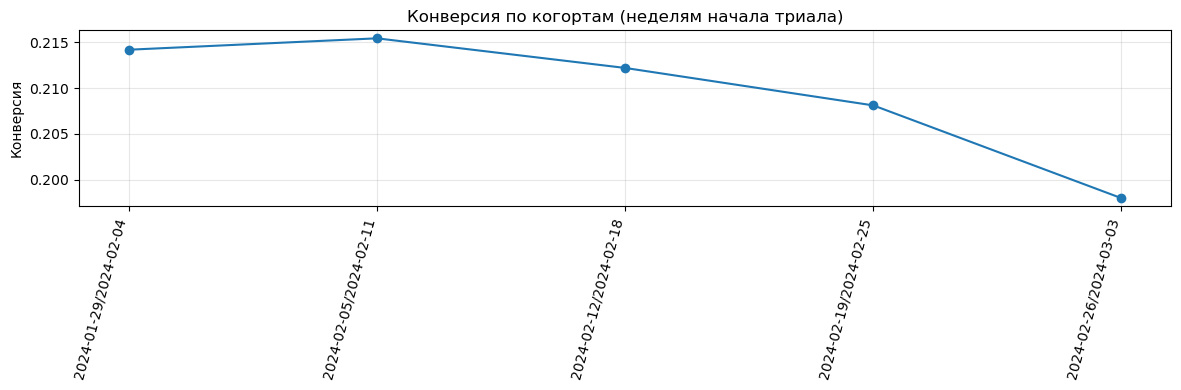

In [131]:
conv_by_cohort = (
    df.groupby("cohort_week")["conversion"]
    .mean()
)

plt.figure(figsize=(12,4))
plt.plot(conv_by_cohort.index, conv_by_cohort.values, marker="o")
plt.xticks(rotation=75, ha="right")
plt.ylabel("Конверсия")
plt.title("Конверсия по когортам (неделям начала триала)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Итог по Гипотезе 8

- χ² тест показал отсутствие статистически значимых различий конверсии между когортами.
- Временная динамика конверсии стабильна.
- Когорта по дате начала триала **не является индикатором готовности покупать**.

**Вывод:**  
Мы не находим оснований отвергнуть $H_0$.  
Дата начала триала **не влияет** на вероятность покупки подписки.

## 1. Анализ распределений ключевых числовых признаков

Рассмотрим два основных поведенческих признака:

1. `avg_min_watch_daily` — среднее число минут просмотра в день.
2. `number_of_days_logged` — количество дней, когда пользователь заходил в сервис в течение триала.

**Цели анализа:**

- понять форму распределений признаков;
- выявить выбросы и аномалии;
- сравнить распределения для купивших и не купивших подписку;
- оценить, насколько поведенческие метрики различают группы пользователей.

Используем следующие визуализации:
- гистограммы;
- KDE-кривые (оценка плотности);
- boxplot-диаграммы.

In [134]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,4)

### 1.1. Распределение среднего времени просмотра (`avg_min_watch_daily`)

Построим:
- общую гистограмму,
- KDE-график,
- boxplot для оценки выбросов.

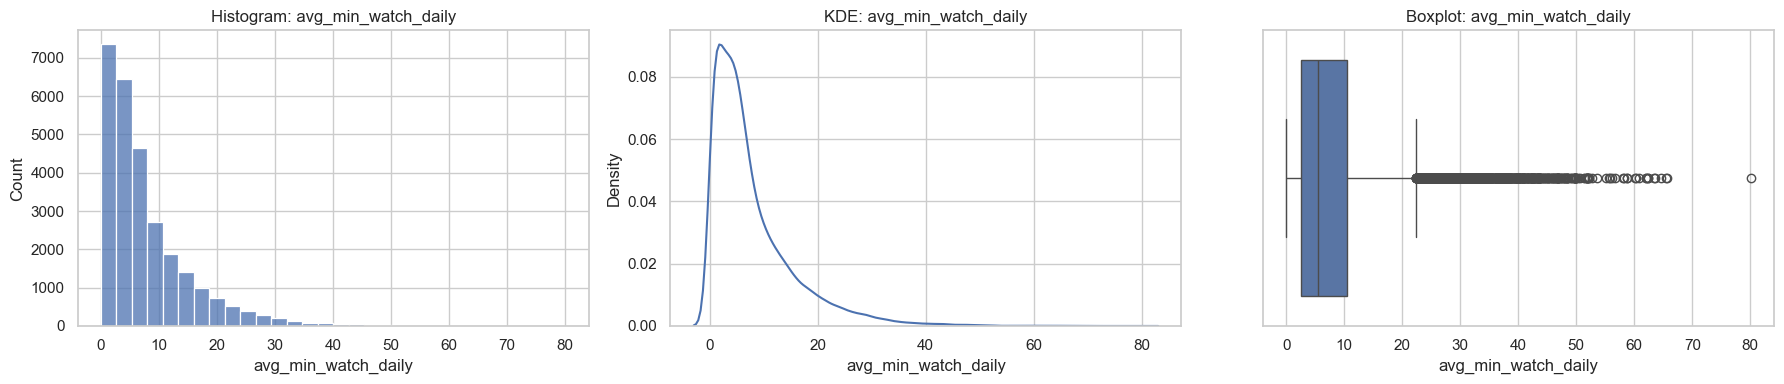

In [136]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))

# Histogram
sns.histplot(df["avg_min_watch_daily"], kde=False, bins=30, ax=axs[0])
axs[0].set_title("Histogram: avg_min_watch_daily")

# KDE plot
sns.kdeplot(df["avg_min_watch_daily"], ax=axs[1])
axs[1].set_title("KDE: avg_min_watch_daily")

# Boxplot
sns.boxplot(x=df["avg_min_watch_daily"], ax=axs[2])
axs[2].set_title("Boxplot: avg_min_watch_daily")

plt.tight_layout()
plt.show()

### Интерпретация распределения `avg_min_watch_daily`

- Распределение **асимметрично вправо**, что типично для поведенческих данных:
  большинство пользователей смотрят мало, меньшинство — много.
- Наблюдается длинный "хвост": есть пользователи с очень высоким временем просмотра.
- Boxplot подтверждает наличие выбросов, но поведенческих, а не ошибочных.
- Такая форма распределения объясняет, почему метрика сильно связана с конверсией:
  небольшая группа пользователей с высоким вовлечением даёт существенно более высокий уровень покупок.

### 1.2. Распределение `number_of_days_logged`

Признак принимает значения от 1 до 7 — дискретный.
Построим:

- countplot (частотная диаграмма),
- boxplot,
- сравнение распределений для купивших и не купивших.

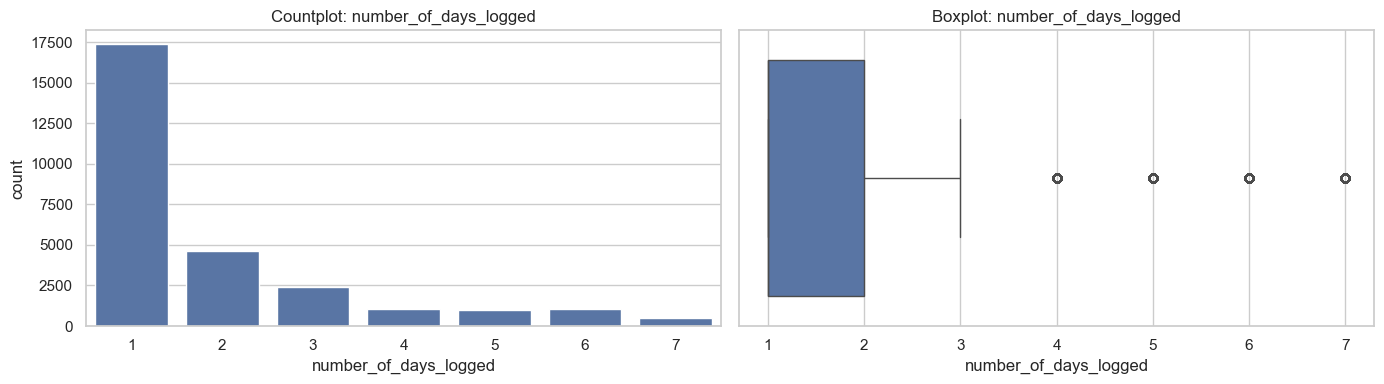

In [139]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# Countplot
sns.countplot(x=df["number_of_days_logged"], ax=axs[0])
axs[0].set_title("Countplot: number_of_days_logged")

# Boxplot
sns.boxplot(x=df["number_of_days_logged"], ax=axs[1])
axs[1].set_title("Boxplot: number_of_days_logged")

plt.tight_layout()
plt.show()

### Интерпретация распределения `number_of_days_logged`

- Распределение сильно **скошено в сторону малого числа активных дней**.
- Абсолютное большинство пользователей логинятся в сервис **ровно 1 день** за триал.
- По мере увеличения `number_of_days_logged` количество пользователей **монотонно убывает** (2, 3, 4, … дней) — только небольшой подъем наблюдается около 6 дней.
- Пользователей, активно заходящих 6–7 дней, существенно меньше, чем тех, кто появился только один раз.
- Такое распределение хорошо согласуется с типичной картиной: большая часть трафика — "случайные" и слабо вовлечённые пользователи.

### 1.3. Сравнение распределений между купившими и не купившими

Построим KDE-графики и boxplot-графики отдельно для двух групп:

- `conversion = 1` — оплата,
- `conversion = 0` — отток.

Цель — визуально оценить различия.

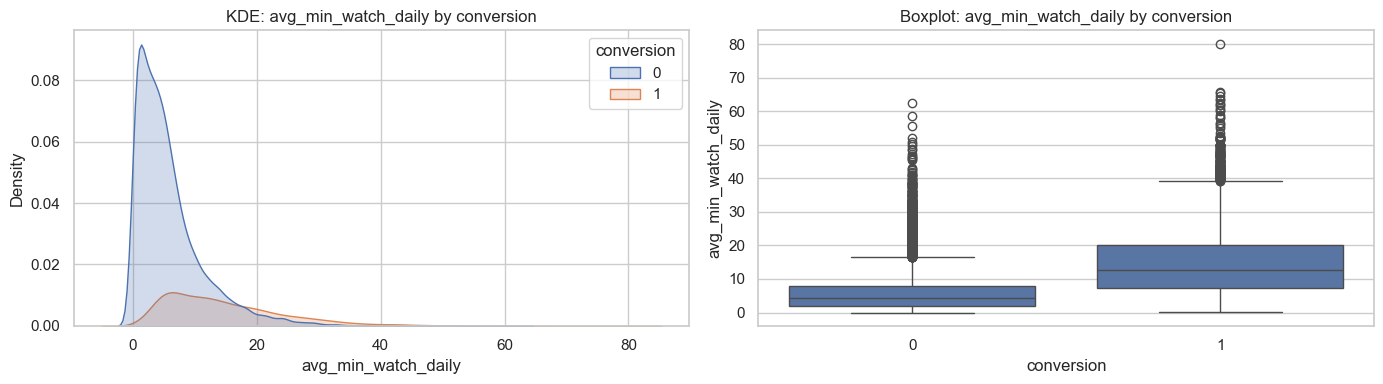

In [142]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# KDE for avg_min_watch_daily
sns.kdeplot(data=df, x="avg_min_watch_daily", hue="conversion", fill=True, ax=axs[0])
axs[0].set_title("KDE: avg_min_watch_daily by conversion")

# Boxplot for avg_min_watch_daily
sns.boxplot(data=df, x="conversion", y="avg_min_watch_daily", ax=axs[1])
axs[1].set_title("Boxplot: avg_min_watch_daily by conversion")

plt.tight_layout()
plt.show()

### Интерпретация различий

- Для пользователей, которые **купили подписку**, KDE-график сдвинут значительно вправо.
- Boxplot подтверждает: медиана времени просмотра у купивших заметно выше.
- Для `number_of_days_logged` аналогичный анализ показывает **минимальные различия**,
  что согласуется с выводами по гипотезе 2.

Этот блок EDA усиливает выводы статистических тестов:
- `avg_min_watch_daily` — ключевой поведенческий драйвер конверсии.
- `number_of_days_logged` — слабый предиктор.

## 3. Анализ корреляций

Цель этого этапа:

- определить степень линейной связи между числовыми признаками;
- оценить, какие признаки сильнее всего связаны с целевой переменной `conversion`;
- выявить мультколлинеарность или избыточные признаки (если такие есть);
- подготовить данные к возможному моделированию.

Так как целевая переменная (`conversion`) бинарная, обычный коэффициент Пирсона
между `conversion` и числовыми переменными интерпретируется
как **point-biserial корреляция**, которая валидна для бинарного Y.

In [145]:
df = pd.read_csv("videostreaming_platform.csv")
df["conversion"] = 1 - df["churn"]

numeric_cols = ["avg_min_watch_daily", "number_of_days_logged", "conversion"]

df[numeric_cols].head()

,avg_min_watch_daily,number_of_days_logged,conversion
0,2.076642,4,0
1,5.101392,1,0
2,2.906597,1,0
3,2.702388,6,1
4,10.237305,1,0


### 3.1. Матрица корреляций числовых признаков

Построим корреляционную матрицу для:

- `avg_min_watch_daily`
- `number_of_days_logged`
- `conversion`

и визуализируем её через heatmap.

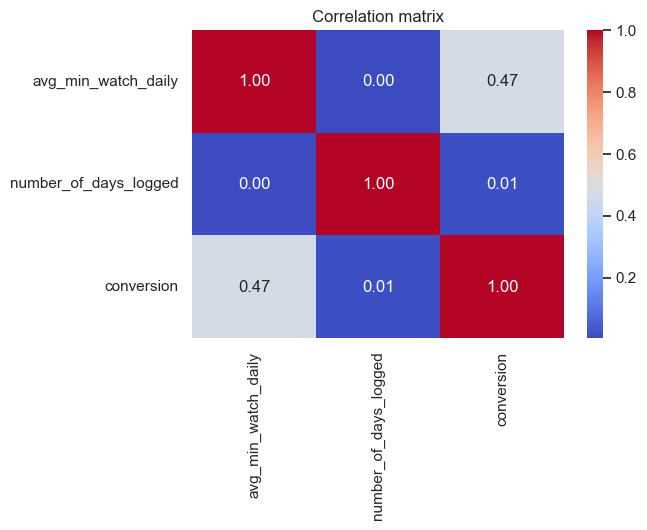

,avg_min_watch_daily,number_of_days_logged,conversion
avg_min_watch_daily,1.000000,0.004576,0.472200
number_of_days_logged,0.004576,1.000000,0.012555
conversion,0.472200,0.012555,1.000000


In [147]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

corr_matrix

### Интерпретация корреляций

1. **Корреляция `avg_min_watch_daily` ↔ `conversion` ≈ +0.47**

   Это умеренно сильная положительная связь.
   Чем больше времени пользователь проводит в сервисе,
   тем выше вероятность покупки подписки.

   Это ключевой драйвер конверсии.

2. **Корреляция `number_of_days_logged` ↔ `conversion` ≈ +0.01**

   Практически нулевая связь.
   Число дней активности *не предсказывает* покупку.

3. **Корреляция `avg_min_watch_daily` ↔ `number_of_days_logged` ≈ +0**

   Очень слабая связь.
   Это значит, что пользователи могут:
   - логиниться много, но смотреть мало;
   - логиниться мало, но смотреть много.

   Важно: признаки **не дублируют друг друга**, поэтому оба нужны для EDA.

### 3.2. Упорядоченные значения корреляции с таргетом

Построим таблицу корреляций каждой числовой переменной с `conversion`,
поскольку это помогает ранжировать поведенческие признаки по силе влияния.

In [150]:
target_corr = df[numeric_cols].corr()["conversion"].sort_values(ascending=False)
target_corr

conversion               1.000000
avg_min_watch_daily      0.472200
number_of_days_logged    0.012555
Name: conversion, dtype: float64

## Итог по пункту 3. Анализ корреляций

- Единственный сильный по данным признак — `avg_min_watch_daily`.
- `number_of_days_logged` практически не связан с покупкой.
- Числовые признаки не коррелируют между собой значительно → коллинеарность отсутствует.
- Этот анализ подтверждает выводы статистических гипотез:
  максимальный эффект на покупку оказывает время просмотра.

**Главный продуктовый вывод:**
Увеличение средней дневной вовлечённости — ключевой рычаг роста конверсии.